# QAOA for UAV Swarm Deployment in ISAC-Assisted Disaster Relief

**Self-contained Jupyter notebook — run cells top to bottom.**

All blocks share the kernel state. No external file imports required.

| Cell | Contents |
|------|----------|
| 1 | Installs & imports |
| 2 | System parameters |
| 3 | Environment (channel, gains, QUBO) |
| 4 | QUBO → Qiskit QuadraticProgram |
| 5 | Exact solver (NumPy reference) |
| 6 | QAOA solver (statevector) |
| 7 | Noisy QAOA solver (Aer) |
| 8 | p-layer sweep |
| 9 | Greedy & random baselines |
| 10 | Comparison table |
| 11 | Figures (all paper plots) |

## Cell 1 — Installs & Imports

In [12]:
# Install required packages (run once; comment out after first run)
# !pip install qiskit qiskit-algorithms qiskit-optimization qiskit-aer --quiet

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from mpl_toolkits.mplot3d import Axes3D
from itertools import combinations
from dataclasses import dataclass
from typing import Tuple, List, Dict, Optional
from enum import Enum
import json

# Qiskit
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit_algorithms import QAOA
from qiskit_algorithms.minimum_eigensolvers import NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import COBYLA, SPSA
from qiskit_algorithms.utils import algorithm_globals
from qiskit.primitives import StatevectorSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit_aer.noise import NoiseModel, depolarizing_error

import qiskit
print(f"Qiskit {qiskit.__version__} — all imports OK")

# Plot style
plt.rcParams.update({
    'font.family': 'serif', 'font.size': 11,
    'axes.labelsize': 12, 'axes.titlesize': 12,
    'legend.fontsize': 10, 'figure.dpi': 110,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
})
COLOURS = {
    'qaoa': '#1f77b4', 'exact': '#2ca02c',
    'greedy': '#ff7f0e', 'random': '#9467bd', 'noise': '#d62728',
}

Qiskit 2.4.2 — all imports OK


## Cell 2 — System Parameters

Change `U`, `G`, `S` here to scale the problem.
For a quick test use `U=2, G=4`. For paper results use `U=3, G=9`.

In [13]:
# ── Physical constants ────────────────────────────────────────────────
C_LIGHT = 3.0e8          # speed of light [m/s]
LN2_VAL = np.log(2)      # ln(2)

# ── Scenario size ─────────────────────────────────────────────────────
U   = 2      # number of UAVs
G   = 4      # candidate 3-D grid points
S   = 3      # number of survivors
Nt  = 4      # antennas per UAV (ULA)

# ── Carrier / bandwidth ───────────────────────────────────────────────
fc      = 2.4e9    # carrier frequency [Hz]
B       = 1e6      # link bandwidth [Hz]

# ── Power / noise ─────────────────────────────────────────────────────
P_max   = 1.0      # max transmit power per UAV [W]  (eq:power_sat)
sigma2  = 1e-9     # AWGN noise variance σ² [W]

# ── Rician channel ────────────────────────────────────────────────────
kappa   = 3.0      # Rician K-factor κ  (eq:rician)

# ── ITU-R LoS model (urban) ───────────────────────────────────────────
a_itu   = 9.61     # ITU-R constant a  (eq:plos)
b_itu   = 0.16     # ITU-R constant b  (eq:plos)

# ── Path loss ─────────────────────────────────────────────────────────
eta_LoS  = 1.0     # LoS  attenuation factor [linear]  (eq:pathloss)
eta_NLoS = 20.0    # NLoS attenuation factor [linear]  (eq:pathloss)

# ── QoS ──────────────────────────────────────────────────────────────
Gamma_min = 1.0    # minimum SINR threshold Γ_min [linear]  (eq:c3)

# ── Collision avoidance ───────────────────────────────────────────────
d_safe  = 10.0     # minimum UAV separation [m]  (eq:c4_geom)

# ── QAOA settings ─────────────────────────────────────────────────────
QAOA_REPS    = 1       # circuit depth p (increase for better solutions)
QAOA_MAXITER = 300     # classical optimiser iterations
SEED         = 42      # reproducibility

n_qubits = U * G
print(f"Problem: U={U} UAVs, G={G} grid pts, S={S} survivors, Nt={Nt} antennas")
print(f"Qubits : n = U×G = {n_qubits}")
print(f"QAOA   : p={QAOA_REPS} layers, maxiter={QAOA_MAXITER}")

Problem: U=2 UAVs, G=4 grid pts, S=3 survivors, Nt=4 antennas
Qubits : n = U×G = 8
QAOA   : p=1 layers, maxiter=300


## Cell 3 — Environment

Builds the 3-D grid, computes all channel/beamforming gains,
assembles the QUBO matrix Q and Ising coefficients J, h, c0.

In [14]:
# ── 3A: Grid generation ──────────────────────────────────────────────
def build_grid(U, G, S, alt=(50.0, 150.0), xy=(0.0, 500.0), seed=42):
    """Generate random 3-D UAV grid points and ground-level survivors.
    Returns p_grid (G,3), q_surv (S,3).  LaTeX eq:dist"""
    rng = np.random.default_rng(seed)
    p_grid = np.hstack([rng.uniform(*xy, (G,2)),
                         rng.uniform(*alt, (G,1))])
    q_surv = np.hstack([rng.uniform(*xy, (S,2)),
                         np.zeros((S,1))])
    return p_grid, q_surv

# ── 3B: Channel geometry ─────────────────────────────────────────────
def dist(pg, qs):
    """eq:dist  d_{g,s} = ‖p_g − q_s‖₂"""
    return float(np.linalg.norm(pg - qs))

def elevation(pg, qs):
    """eq:elevation  θ_{g,s} = arctan(Δz / √(Δx²+Δy²))"""
    d = pg - qs
    return float(np.arctan2(d[2], np.sqrt(d[0]**2 + d[1]**2)))

def azimuth(pg, qs):
    d = qs - pg
    return float(np.arctan2(d[1], d[0]))

def plos(theta, a=9.61, b=0.16):
    """eq:plos  P_LoS(θ) = 1/(1 + a·exp(−b·(θ_deg − a)))"""
    return float(1.0 / (1.0 + a * np.exp(-b * (np.degrees(theta) - a))))

def path_loss(pg, qs):
    """eq:pathloss  L_{g,s} = (c/4πf_c d)² · [P_LoS·η_LoS + P_NLoS·η_NLoS]⁻¹"""
    d   = dist(pg, qs)
    th  = elevation(pg, qs)
    Pl  = plos(th)
    return float((C_LIGHT / (4*np.pi*fc*d))**2 / (Pl*eta_LoS + (1-Pl)*eta_NLoS))

def steering(theta, phi, Nt):
    """eq:steering  a(θ,φ) = (1/√Nt)·[1, e^{jπsinθcosφ}, ...]"""
    inc = np.pi * np.sin(theta) * np.cos(phi)
    return (1/np.sqrt(Nt)) * np.exp(1j * inc * np.arange(Nt))

def channel_vec(pg, qs, rng):
    """eq:rician  h_{u,s}(g) = √L·[√(κ/(κ+1))·a + √(1/(κ+1))·h̃]"""
    L   = path_loss(pg, qs)
    th  = elevation(pg, qs)
    phi = azimuth(pg, qs)
    a   = steering(th, phi, Nt)
    h_t = (rng.standard_normal(Nt) + 1j*rng.standard_normal(Nt)) / np.sqrt(2)
    return np.sqrt(L) * (np.sqrt(kappa/(kappa+1))*a + np.sqrt(1/(kappa+1))*h_t)

# ── 3C: MRT beamformer ───────────────────────────────────────────────
def mrt(h):
    """eq:mrt  w = √P_max · h/‖h‖    eq:power_sat: ‖w‖²=P_max"""
    return np.sqrt(P_max) * h / np.linalg.norm(h)

def signal_gain(h, w):
    """eq:signal_gain  G_{u,g,s} = |h^H w|² = P_max·‖h‖²"""
    v = np.vdot(h, w)
    return float(np.real(v * np.conj(v)))

def interference_gain(h_vgp, w_ug):
    """eq:int_gain  I_{u,v,g,g',s} = |h_{v,s}(g')^H · w_{u,s}(g)|²"""
    v = np.vdot(h_vgp, w_ug)
    return float(np.real(v * np.conj(v)))

# ── 3D: Pre-compute all gains ─────────────────────────────────────────
rng_env = np.random.default_rng(SEED)
p_grid, q_surv = build_grid(U, G, S, seed=SEED)

# Channel H[u,g,s] ∈ ℂ^Nt and beamformer W[u,g,s] ∈ ℂ^Nt
H = np.zeros((U,G,S,Nt), dtype=np.complex128)
W = np.zeros((U,G,S,Nt), dtype=np.complex128)
for u in range(U):
    for g in range(G):
        for s in range(S):
            H[u,g,s] = channel_vec(p_grid[g], q_surv[s], rng_env)
            W[u,g,s] = mrt(H[u,g,s])

# Signal gain table G_table[u,g,s]  (eq:signal_gain)
G_table = np.zeros((U,G,S))
for u in range(U):
    for g in range(G):
        for s in range(S):
            G_table[u,g,s] = signal_gain(H[u,g,s], W[u,g,s])

# Interference gain I_table[u,g,v,g',s]  (eq:int_gain)
I_table = np.zeros((U,G,U,G,S))
for u in range(U):
    for g in range(G):
        for v in range(U):
            for gp in range(G):
                if (u,g)==(v,gp): continue
                for s in range(S):
                    I_table[u,g,v,gp,s] = interference_gain(H[v,gp,s], W[u,g,s])

# ── 3E: Rate linearisation coefficients ──────────────────────────────
# eq:acoeff  a_{u,g,s} = G_{u,g,s} / (σ²·ln2)
a_coeff = G_table / (sigma2 * LN2_VAL)

# eq:bcoeff  b_{ug,vg',s} = G_{u,g,s}·I_{u,v,g,g',s} / (σ⁴·(ln2)²)
b_coeff = np.zeros((U,G,U,G,S))
denom   = sigma2**2 * LN2_VAL**2
for u in range(U):
    for g in range(G):
        for v in range(U):
            for gp in range(G):
                if (u,g)==(v,gp): continue
                b_coeff[u,g,v,gp,:] = G_table[u,g,:]*I_table[u,g,v,gp,:]/denom

# ── 3F: Exclusion set E  (eq:exclusion) ──────────────────────────────
exclusion = [(g,gp) for g in range(G) for gp in range(G)
             if g!=gp and np.linalg.norm(p_grid[g]-p_grid[gp]) < d_safe]

# ── 3G: Penalty weights  (eq:lambda_hard / eq:lambda_soft) ───────────
lam_hard  = 1.5 * B * float(np.sum(a_coeff))
lambda1   = lam_hard
lambda2   = lam_hard
lambda3   = 0.10 * lam_hard
lambda4   = lam_hard
CONST_OFFSET = lambda1*U + lambda3*S*Gamma_min**2   # penalty constants not in Q

# ── 3H: QUBO matrix Q  (eq:Qdiag / eq:Qoffdiag) ─────────────────────
excl_set = set(exclusion)
Q = np.zeros((n_qubits, n_qubits))

def idx(u,g): return u*G+g

for u in range(U):
    for g in range(G):
        i        = idx(u,g)
        sa       = float(np.sum(a_coeff[u,g,:]))
        sa2      = float(np.sum(a_coeff[u,g,:]**2))
        # eq:Qdiag (with P3 diagonal correction: +λ3·Σa²)
        Q[i,i]   = -B*sa - lambda1 - 2*lambda3*Gamma_min*sa + lambda3*sa2

        for v in range(U):
            for gp in range(G):
                if idx(u,g) >= idx(v,gp): continue
                j = idx(v,gp)
                # interference (both directions, eq:Qoffdiag)
                int_t = B*(float(np.sum(b_coeff[u,g,v,gp,:]))
                          +float(np.sum(b_coeff[v,gp,u,g,:])))
                # C1: same UAV, diff grid
                c1_t  = 2*lambda1 if (u==v and g!=gp) else 0.0
                # C2: diff UAV, same grid
                c2_t  = lambda2   if (u!=v and g==gp) else 0.0
                # C3: cross terms (×2 for symmetry)
                c3_t  = 2*lambda3*float(np.sum(a_coeff[u,g,:]*a_coeff[v,gp,:]))
                # C4: collision exclusion
                c4_t  = lambda4   if (u!=v and (g,gp) in excl_set) else 0.0
                Q[i,j] = int_t + c1_t + c2_t + c3_t + c4_t

# ── 3I: Ising J, h, c0  (eq:Jij / eq:hi / eq:c0) ────────────────────
# J upper-triangular; h computed from upper-tri Q
J_ising  = np.zeros((n_qubits, n_qubits))
h_ising  = np.zeros(n_qubits)
c0_ising = 0.0
for i in range(n_qubits):
    c0_ising += Q[i,i]/2; h_ising[i] -= Q[i,i]/2
for i in range(n_qubits):
    for j in range(i+1, n_qubits):
        J_ising[i,j]  = Q[i,j]/4
        c0_ising     += Q[i,j]/4
        h_ising[i]   -= Q[i,j]/4
        h_ising[j]   -= Q[i,j]/4

# ── 3J: Evaluation helpers ────────────────────────────────────────────
def sinr_exact(x, s):
    """eq:sinr — exact SINR at survivor s for placement matrix x (U,G)"""
    num = sum(x[u,g]*G_table[u,g,s] for u in range(U) for g in range(G))
    inter = sum(I_table[u,g,v,gp,s]*x[u,g]*x[v,gp]
                for u in range(U) for g in range(G)
                for v in range(U) for gp in range(G) if (u,g)!=(v,gp))
    return num / (inter + sigma2)

def sum_rate_exact(x):
    """eq:rate + eq:rsum_expanded — exact sum-rate [bps]"""
    return sum(B*np.log2(1+sinr_exact(x,s)) for s in range(S))

def check_constraints(x):
    """Check C1–C4 feasibility for placement matrix x (U,G)."""
    c1 = all(x[u,:].sum()==1 for u in range(U))
    c2 = all(x[:,g].sum()<=1 for g in range(G))
    c3 = all(float(np.sum(a_coeff[:,:,s]*x))>=Gamma_min for s in range(S))
    c4 = all(x[u,g]+x[v,gp]<=1
             for u,v in combinations(range(U),2)
             for g,gp in exclusion)
    return {'C1':c1,'C2':c2,'C3':c3,'C4':c4,'feasible':c1 and c2 and c4}

def evaluate(x):
    """Full evaluation of placement matrix x (U,G)."""
    sinrs = [sinr_exact(x,s) for s in range(S)]
    rates = [B*np.log2(1+si) for si in sinrs]
    return {
        'sinr': sinrs, 'rate': rates,
        'sum_rate': sum(rates),
        'constraints': check_constraints(x),
    }

def hamiltonian(x):
    """eq:Hc_full — total QUBO Hamiltonian value."""
    xv  = x.flatten().astype(float)
    hqp = float(xv @ Q @ xv) + CONST_OFFSET
    return hqp

print(f"Environment built:")
print(f"  G_table  : {G_table.shape}  (min={G_table.min():.3e}, max={G_table.max():.3e})")
print(f"  a_coeff  : {a_coeff.shape}  (min={a_coeff.min():.3e})")
print(f"  Q matrix : {Q.shape}")
print(f"  |E|      : {len(exclusion)} exclusion pairs")
print(f"  λ1=λ2=λ4 : {lambda1:.4e}")
print(f"  λ3       : {lambda3:.4e}")
print(f"  c0_ising : {c0_ising:.4e}")

# Quick sanity: Ising H should match x^TQx
_x  = np.zeros((U,G),dtype=int); _x[0,0]=1
_xv = _x.flatten().astype(float)
_z  = 1-2*_xv
_hq = float(_xv @ Q @ _xv)
_hi = float(_z @ J_ising @ _z + h_ising @ _z + c0_ising)
print(f"  Ising check: H_Q={_hq:.4e}  H_I={_hi:.4e}  match={abs(_hq-_hi)<1e-4}")

Environment built:
  G_table  : (2, 4, 3)  (min=2.485e-11, max=3.374e-09)
  a_coeff  : (2, 4, 3)  (min=3.585e-02)
  Q matrix : (8, 8)
  |E|      : 0 exclusion pairs
  λ1=λ2=λ4 : 2.4685e+07
  λ3       : 2.4685e+06
  c0_ising : 1.9597e+08
  Ising check: H_Q=-2.8779e+07  H_I=-2.8779e+07  match=True


## Cell 4 — QUBO → Qiskit QuadraticProgram

Converts the Q matrix into a Qiskit `QuadraticProgram` and verifies
that `fval(x) = x^T Q x` for 20 random binary vectors.

In [15]:
# ── Variable names: 'x{u}_{g}' at index i = u*G + g ──────────────────
var_names = [f'x{u}_{g}' for u in range(U) for g in range(G)]

# ── Build QuadraticProgram from Q  (eq:qubo_matrix) ──────────────────
qp = QuadraticProgram(name='ISAC_UAV')
for name in var_names:
    qp.binary_var(name)

linear    = {var_names[i]: float(Q[i,i]) for i in range(n_qubits) if abs(Q[i,i])>1e-15}
quadratic = {(var_names[i], var_names[j]): float(Q[i,j])
             for i in range(n_qubits) for j in range(i+1,n_qubits)
             if abs(Q[i,j])>1e-15}
qp.minimize(linear=linear, quadratic=quadratic)

# ── Verification: fval(x) == x^TQx for 20 random x ──────────────────
rng_v = np.random.default_rng(0)
errors = []
for _ in range(20):
    xv   = rng_v.integers(0,2,n_qubits).astype(float)
    xd   = {var_names[i]: xv[i] for i in range(n_qubits)}
    fqp  = qp.objective.evaluate(xd)
    fQ   = float(xv @ Q @ xv)
    errors.append(abs(fqp-fQ)/(abs(fQ)+1e-30))

print(f"QuadraticProgram built: {qp.get_num_vars()} binary variables")
print(f"Max relative error over 20 random x: {max(errors):.2e}")
print(f"Verification: {'✓ PASS' if max(errors)<1e-6 else '✗ FAIL'}")

QuadraticProgram built: 8 binary variables
Max relative error over 20 random x: 4.72e-16
Verification: ✓ PASS


## Cell 5 — Exact Reference Solver (NumPy)

Finds the true optimal solution by exhaustive eigensolver.
Only feasible for small `n ≤ 20` qubits. Used to compute the approximation ratio.

In [16]:
# ── Exact solve via NumPy minimum eigensolver ─────────────────────────
exact_solver = MinimumEigenOptimizer(NumPyMinimumEigensolver())
exact_result = exact_solver.solve(qp)

x_exact_vec = np.array(exact_result.x)
x_exact     = x_exact_vec.reshape(U,G).astype(int)
eval_exact  = evaluate(x_exact)
fval_exact  = float(exact_result.fval)

print("=" * 55)
print("  EXACT OPTIMAL SOLUTION")
print("=" * 55)
print(f"  Placement matrix x*:"); print(x_exact)
print(f"  QUBO fval*          : {fval_exact:.6e}")
print(f"  Sum-rate*           : {eval_exact['sum_rate']:.4e} bps")
print(f"  SINR per survivor   : {[f'{v:.3f}' for v in eval_exact['sinr']]}")
print(f"  C1 (one-hot)        : {eval_exact['constraints']['C1']}")
print(f"  C2 (no co-loc)      : {eval_exact['constraints']['C2']}")
print(f"  C3 (SINR floor)     : {eval_exact['constraints']['C3']}")
print(f"  C4 (separation)     : {eval_exact['constraints']['C4']}")
print(f"  Feasible            : {eval_exact['constraints']['feasible']}")
print("=" * 55)

  EXACT OPTIMAL SOLUTION
  Placement matrix x*:
[[0 0 1 0]
 [0 1 0 0]]
  QUBO fval*          : -5.429440e+07
  Sum-rate*           : 1.7159e+06 bps
  SINR per survivor   : ['1.283', '0.178', '0.221']
  C1 (one-hot)        : True
  C2 (no co-loc)      : True
  C3 (SINR floor)     : False
  C4 (separation)     : True
  Feasible            : True


## Cell 6 — QAOA Solver (Statevector — Noiseless)

Runs QAOA using Qiskit's exact statevector simulation.
Adjust `QAOA_REPS` in Cell 2 to change circuit depth p.

In [17]:
# ── Convergence tracker ───────────────────────────────────────────────
qaoa_counts_sv  = []
qaoa_values_sv  = []
qaoa_params_sv  = []

def callback_sv(eval_count, params, mean, metadata):
    qaoa_counts_sv.append(eval_count)
    qaoa_values_sv.append(float(mean))
    qaoa_params_sv.append(params.copy())
    if eval_count % 30 == 0 or eval_count == 1:
        print(f"    iter {eval_count:4d}   ⟨H_C⟩ = {mean:.6e}")

# ── QAOA with StatevectorSampler  (eq:qaoa_state) ─────────────────────
algorithm_globals.random_seed = SEED
rng_init = np.random.default_rng(SEED)
init_pt  = rng_init.uniform(0, np.pi, size=2*QAOA_REPS)

print(f"Running QAOA  p={QAOA_REPS}  backend=StatevectorSampler")
print(f"Initial γ: {np.round(init_pt[:QAOA_REPS],3)}")
print(f"Initial β: {np.round(init_pt[QAOA_REPS:],3)}")
print()

qaoa_sv = QAOA(
    sampler       = StatevectorSampler(seed=SEED),
    optimizer     = COBYLA(maxiter=QAOA_MAXITER),
    reps          = QAOA_REPS,
    initial_point = init_pt,
    callback      = callback_sv,
)
result_sv  = MinimumEigenOptimizer(qaoa_sv).solve(qp)
x_qaoa_vec = np.array(result_sv.x)
fval_sv    = float(result_sv.fval)

print(f"\nConverged after {len(qaoa_counts_sv)} evaluations")
print(f"Final ⟨H_C⟩ = {qaoa_values_sv[-1]:.6e}")
print(f"Solution x  = {x_qaoa_vec}")
print(f"fval        = {fval_sv:.6e}")

# ── Feasibility repair: project to C1 feasible subspace ──────────────
def repair(xvec):
    """For each UAV u, keep only the grid with highest signal gain."""
    xm = xvec.reshape(U,G).copy().astype(float)
    xo = np.zeros((U,G),dtype=int)
    scores = G_table.sum(axis=2)    # (U,G) — total gain per (u,g)
    for u in range(U):
        cands = np.where(xm[u]>0.5)[0]
        g_best = (int(cands[np.argmax(scores[u,cands])]) if len(cands)>0
                  else int(np.argmax(scores[u])))
        xo[u, g_best] = 1
    return xo

x_qaoa    = repair(x_qaoa_vec)
eval_qaoa = evaluate(x_qaoa)
AR_qubo   = fval_sv / fval_exact
AR_rate   = eval_qaoa['sum_rate'] / eval_exact['sum_rate']

print()
print("=" * 55)
print("  QAOA RESULT (statevector)")
print("=" * 55)
print(f"  Placement:"); print(x_qaoa)
print(f"  Sum-rate  : {eval_qaoa['sum_rate']:.4e} bps")
print(f"  AR (QUBO) : {AR_qubo:.4f}  (1=optimal)")
print(f"  AR (rate) : {AR_rate:.4f}  (1=optimal)")
print(f"  Feasible  : {eval_qaoa['constraints']['feasible']}")
print("=" * 55)

Running QAOA  p=1  backend=StatevectorSampler
Initial γ: [2.431]
Initial β: [1.379]

    iter    1   ⟨H_C⟩ = 1.213446e+07
    iter   30   ⟨H_C⟩ = -2.853265e+07

Converged after 31 evaluations
Final ⟨H_C⟩ = -3.341859e+06
Solution x  = [1. 0. 0. 0. 0. 0. 1. 0.]
fval        = -5.426604e+07

  QAOA RESULT (statevector)
  Placement:
[[1 0 0 0]
 [0 0 1 0]]
  Sum-rate  : 7.9805e+05 bps
  AR (QUBO) : 0.9995  (1=optimal)
  AR (rate) : 0.4651  (1=optimal)
  Feasible  : True


## Cell 7 — QAOA Solver (Noisy — Aer Depolarising)

Replaces the exact sampler with Aer + depolarising noise model.
Adjust `p_1q` (single-qubit error) and `p_2q` (two-qubit error).

In [18]:
# ── Noise parameters ─────────────────────────────────────────────────
p_1q_err = 0.001    # single-qubit depolarising rate
p_2q_err = 0.010    # two-qubit depolarising rate
SHOTS    = 1024
AER_BASIS_GATES = ['h', 'rx', 'rz', 'rzz', 'cx', 'measure']

# ── Build noise model ─────────────────────────────────────────────────
nm = NoiseModel()
nm.add_all_qubit_quantum_error(depolarizing_error(p_1q_err, 1),
                                ['h','rx','rz','u'])
nm.add_all_qubit_quantum_error(depolarizing_error(p_2q_err, 2),
                                ['cx','rzz','ecr'])

aer_sampler = AerSampler(
    default_shots = SHOTS,
    seed          = SEED,
    options       = {'backend_options': {'noise_model': nm}},
)
aer_pass_manager = generate_preset_pass_manager(
    optimization_level = 1,
    basis_gates        = AER_BASIS_GATES,
    seed_transpiler    = SEED,
)

# ── Convergence tracker ───────────────────────────────────────────────
qaoa_counts_noisy = []
qaoa_values_noisy = []

def callback_noisy(eval_count, params, mean, metadata):
    qaoa_counts_noisy.append(eval_count)
    qaoa_values_noisy.append(float(mean))
    if eval_count % 30 == 0 or eval_count == 1:
        print(f"    iter {eval_count:4d}   ⟨H_C⟩ = {mean:.6e}")

# ── QAOA with noisy Aer sampler ───────────────────────────────────────
algorithm_globals.random_seed = SEED
print(f"Running QAOA  p={QAOA_REPS}  backend=AerSampler (noisy)")
print(f"p_1q={p_1q_err}  p_2q={p_2q_err}  shots={SHOTS}")
print()

qaoa_noisy = QAOA(
    sampler       = aer_sampler,
    optimizer     = SPSA(maxiter=QAOA_MAXITER),   # SPSA handles shot noise
    reps          = QAOA_REPS,
    initial_point = init_pt,
    callback      = callback_noisy,
    transpiler    = aer_pass_manager,
)
result_noisy  = MinimumEigenOptimizer(qaoa_noisy).solve(qp)
x_noisy_vec   = np.array(result_noisy.x)
fval_noisy    = float(result_noisy.fval)

x_noisy       = repair(x_noisy_vec)
eval_noisy    = evaluate(x_noisy)
AR_qubo_noisy = fval_noisy / fval_exact
AR_rate_noisy = eval_noisy['sum_rate'] / eval_exact['sum_rate']

print(f"\nFinal ⟨H_C⟩ = {qaoa_values_noisy[-1]:.6e}")
print()
print("=" * 55)
print("  QAOA RESULT (noisy Aer)")
print("=" * 55)
print(f"  Placement:"); print(x_noisy)
print(f"  Sum-rate  : {eval_noisy['sum_rate']:.4e} bps")
print(f"  AR (QUBO) : {AR_qubo_noisy:.4f}")
print(f"  AR (rate) : {AR_rate_noisy:.4f}")
print(f"  Feasible  : {eval_noisy['constraints']['feasible']}")
print("=" * 55)

Running QAOA  p=1  backend=AerSampler (noisy)
p_1q=0.001  p_2q=0.01  shots=1024

    iter    1   ⟨H_C⟩ = -3.389681e+05
    iter   30   ⟨H_C⟩ = -3.984589e+06
    iter   60   ⟨H_C⟩ = -2.257708e+06
    iter   90   ⟨H_C⟩ = -3.428039e+06
    iter  120   ⟨H_C⟩ = 4.610466e+06
    iter  150   ⟨H_C⟩ = -4.285863e+06
    iter  180   ⟨H_C⟩ = 1.055451e+07
    iter  210   ⟨H_C⟩ = 9.441296e+06
    iter  240   ⟨H_C⟩ = -6.947666e+06
    iter  270   ⟨H_C⟩ = 1.125051e+06
    iter  300   ⟨H_C⟩ = -2.833515e+06
    iter  330   ⟨H_C⟩ = -1.050600e+07
    iter  360   ⟨H_C⟩ = -6.609437e+04
    iter  390   ⟨H_C⟩ = -9.053610e+05
    iter  420   ⟨H_C⟩ = -3.357561e+05
    iter  450   ⟨H_C⟩ = -6.033214e+05
    iter  480   ⟨H_C⟩ = -6.302496e+04
    iter  510   ⟨H_C⟩ = -3.263166e+06
    iter  540   ⟨H_C⟩ = -7.592146e+05
    iter  570   ⟨H_C⟩ = 1.144494e+06
    iter  600   ⟨H_C⟩ = -4.488705e+06
    iter  630   ⟨H_C⟩ = -8.201185e+06

Final ⟨H_C⟩ = -4.040573e+06

  QAOA RESULT (noisy Aer)
  Placement:
[[0 0 1 0]
 [0 1 0 

## Cell 8 — p-Layer Sweep

Runs QAOA for p = 1, 2, 3 and collects approximation ratio vs circuit depth.

In [19]:
P_VALUES  = [1, 2, 3]   # change to [1,2,3,4,5] for more layers
sweep_results = []
prev_params   = None

print(f"Sweeping p = {P_VALUES}   backend=StatevectorSampler")
print(f"Exact fval* = {fval_exact:.6e}")
print()

for p in P_VALUES:
    # Warm-start: extend previous parameters with small perturbation
    rng_p = np.random.default_rng(SEED + p)
    if prev_params is None:
        ip = rng_p.uniform(0, np.pi, 2*p)
    else:
        pp = len(prev_params)//2
        gam = np.append(prev_params[:pp],
                        prev_params[pp-1] + rng_p.uniform(-0.1,0.1))
        bet = np.append(prev_params[pp:],
                        prev_params[-1]   + rng_p.uniform(-0.1,0.1))
        ip  = np.concatenate([gam, bet])

    counts_p = []; values_p = []
    def _cb(ec, pa, mn, md):
        counts_p.append(ec); values_p.append(float(mn))

    algorithm_globals.random_seed = SEED
    qaoa_p = QAOA(
        sampler       = StatevectorSampler(seed=SEED),
        optimizer     = COBYLA(maxiter=200),
        reps          = p,
        initial_point = ip,
        callback      = _cb,
    )
    res_p = MinimumEigenOptimizer(qaoa_p).solve(qp)
    xvp   = np.array(res_p.x)
    fvp   = float(res_p.fval)
    xp    = repair(xvp)
    evp   = evaluate(xp)

    ar_q  = fvp / fval_exact
    ar_r  = evp['sum_rate'] / eval_exact['sum_rate']

    sweep_results.append({
        'p': p, 'fval': fvp,
        'sum_rate': evp['sum_rate'],
        'AR_qubo': ar_q, 'AR_rate': ar_r,
        'feasible': evp['constraints']['feasible'],
        'n_evals': len(counts_p),
        'counts': counts_p, 'values': values_p,
    })
    print(f"  p={p}  fval={fvp:.4e}  AR_qubo={ar_q:.4f}  "
          f"AR_rate={ar_r:.4f}  evals={len(counts_p)}")
    prev_params = res_p.groundstate_energy_result.optimal_point if hasattr(
        res_p, 'groundstate_energy_result') else ip

Sweeping p = [1, 2, 3]   backend=StatevectorSampler
Exact fval* = -5.429440e+07

  p=1  fval=-5.4294e+07  AR_qubo=1.0000  AR_rate=1.0000  evals=30
  p=2  fval=-5.4294e+07  AR_qubo=1.0000  AR_rate=1.0000  evals=26
  p=3  fval=-5.4294e+07  AR_qubo=1.0000  AR_rate=1.0000  evals=41


## Cell 9 — Classical Baselines

Greedy (max-rate strategy) and random placement baselines.

In [20]:
# ── 9A: Greedy baseline (max marginal rate) ───────────────────────────
x_greedy = np.zeros((U,G), dtype=int)
for u in range(U):
    best_g, best_r = 0, -np.inf
    for g in range(G):
        x_greedy[u,g] = 1
        r = sum_rate_exact(x_greedy)
        if r > best_r: best_r, best_g = r, g
        x_greedy[u,g] = 0
    x_greedy[u, best_g] = 1
eval_greedy = evaluate(x_greedy)

# ── 9B: Random baseline (Monte Carlo) ────────────────────────────────
rng_rand  = np.random.default_rng(0)
rand_rates = []
for _ in range(200):
    xr = np.zeros((U,G), dtype=int)
    for u in range(U): xr[u, rng_rand.integers(G)] = 1
    rand_rates.append(sum_rate_exact(xr))
rand_mean = float(np.mean(rand_rates))
rand_std  = float(np.std(rand_rates))

print("Greedy placement:")
print(x_greedy)
print(f"  Sum-rate : {eval_greedy['sum_rate']:.4e} bps")
print(f"  Feasible : {eval_greedy['constraints']['feasible']}")
print()
print(f"Random (200 trials):")
print(f"  Mean : {rand_mean:.4e} ± {rand_std:.2e} bps")

Greedy placement:
[[0 0 0 1]
 [0 0 0 1]]
  Sum-rate : 2.5212e+06 bps
  Feasible : False

Random (200 trials):
  Mean : 1.6992e+06 ± 7.00e+05 bps


## Cell 10 — Comparison Table

In [21]:
def fmt(v): return f"{v:.4e}" if not (v!=v) else "    —  "

header = f"{'Method':<22}  {'Sum-Rate (bps)':>16}  {'AR rate':>8}  {'AR QUBO':>8}  {'Feasible':>8}"
sep    = "─" * 70
R_OPT  = eval_exact['sum_rate']
F_OPT  = fval_exact

methods = [
    ("Exact (NumPy)",    R_OPT,                  F_OPT,       eval_exact['constraints']['feasible']),
    ("Greedy (rate)",    eval_greedy['sum_rate'], float('nan'),eval_greedy['constraints']['feasible']),
    ("Random (mean)",    rand_mean,               float('nan'),None),
    ("QAOA SV",          eval_qaoa['sum_rate'],   fval_sv,     eval_qaoa['constraints']['feasible']),
    ("QAOA Noisy",       eval_noisy['sum_rate'],  fval_noisy,  eval_noisy['constraints']['feasible']),
]
for r in sweep_results:
    methods.append((f"QAOA p={r['p']}",
                    r['sum_rate'], r['fval'], r['feasible']))

print(sep); print(header); print(sep)
for name, rate, fval, feas in methods:
    ar_r = rate/R_OPT if R_OPT else float('nan')
    ar_q = fval/F_OPT if (F_OPT and not (fval!=fval)) else float('nan')
    fe   = '✓' if feas is True else ('✗' if feas is False else '?')
    print(f"{name:<22}  {fmt(rate):>16}  {ar_r:>8.4f}  "
          f"{fmt(ar_q):>8}  {fe:>8}")
print(sep)

──────────────────────────────────────────────────────────────────────
Method                    Sum-Rate (bps)   AR rate   AR QUBO  Feasible
──────────────────────────────────────────────────────────────────────
Exact (NumPy)                 1.7159e+06    1.0000  1.0000e+00         ✓
Greedy (rate)                 2.5212e+06    1.4693       —           ✗
Random (mean)                 1.6992e+06    0.9903       —           ?
QAOA SV                       7.9805e+05    0.4651  9.9948e-01         ✓
QAOA Noisy                    1.7159e+06    1.0000  1.0000e+00         ✓
QAOA p=1                      1.7159e+06    1.0000  1.0000e+00         ✓
QAOA p=2                      1.7159e+06    1.0000  1.0000e+00         ✓
QAOA p=3                      1.7159e+06    1.0000  1.0000e+00         ✓
──────────────────────────────────────────────────────────────────────


## Cell 11 — Figures

All paper-quality plots generated inline.

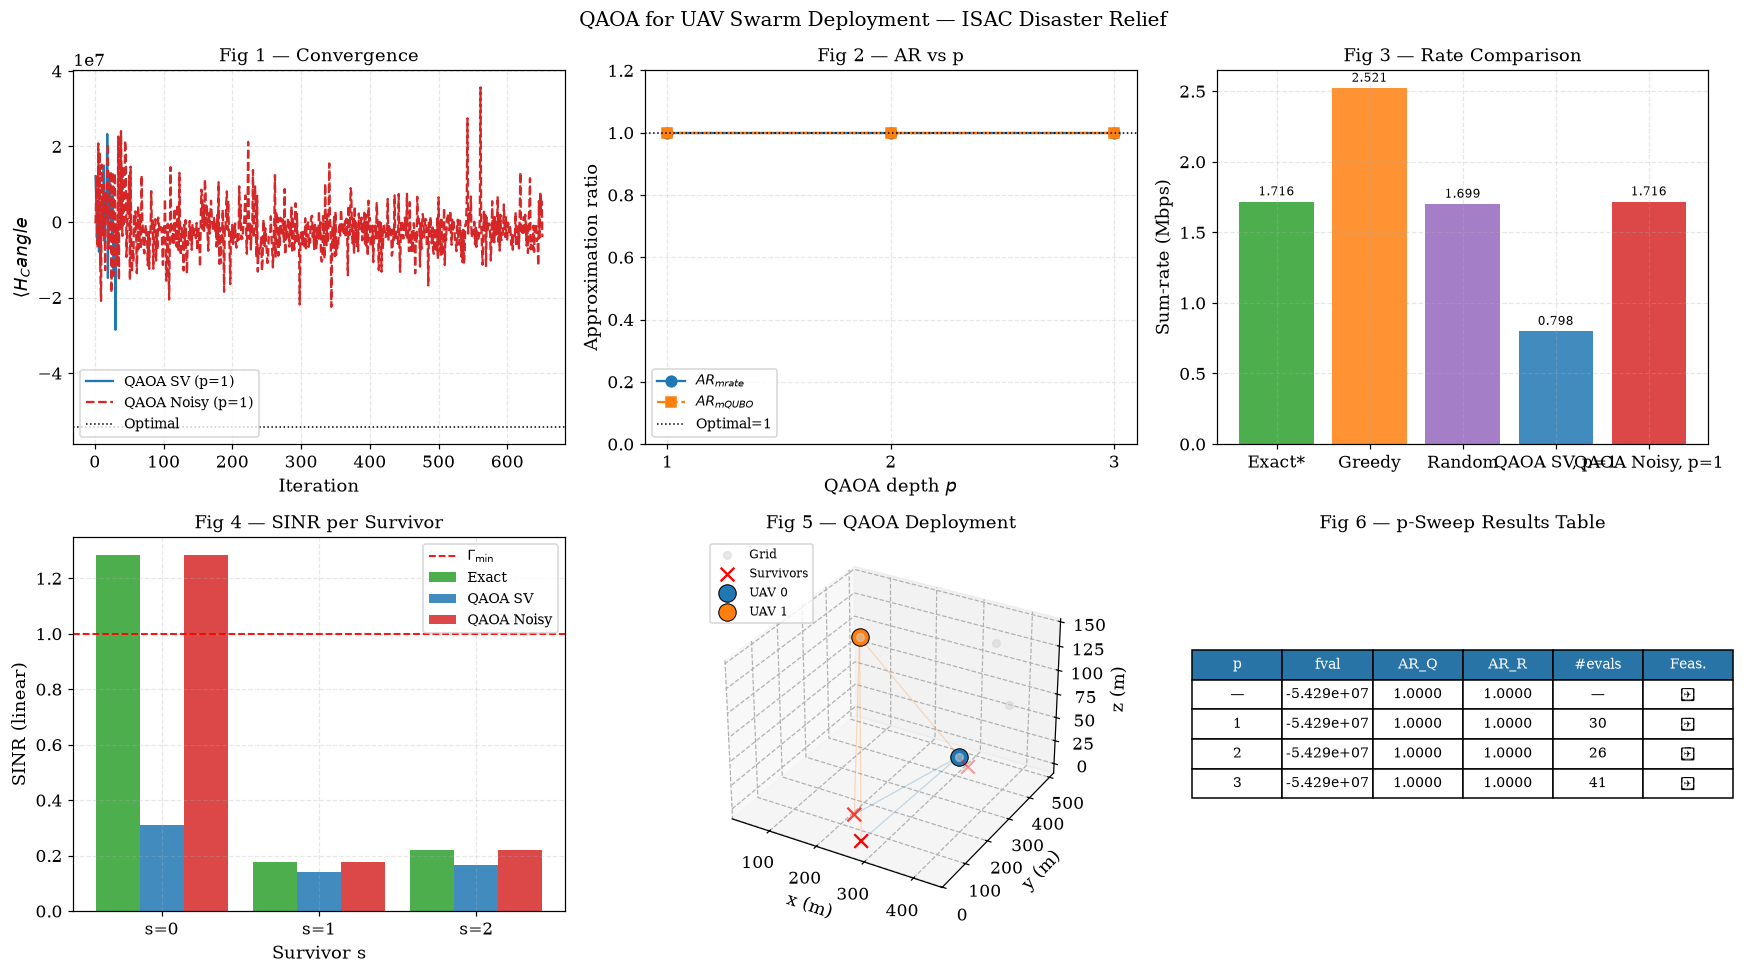

Figures saved to qaoa_isac_figures.pdf


In [24]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('QAOA for UAV Swarm Deployment — ISAC Disaster Relief', fontsize=13)

# ── Fig 1: Convergence ────────────────────────────────────────────────
ax = axes[0,0]
ax.plot(qaoa_counts_sv,    qaoa_values_sv,    label=f'QAOA SV (p={QAOA_REPS})',
        color=COLOURS['qaoa'])
ax.plot(qaoa_counts_noisy, qaoa_values_noisy, label=f'QAOA Noisy (p={QAOA_REPS})',
        color=COLOURS['noise'], linestyle='--')
ax.axhline(fval_exact, color='k', linestyle=':', linewidth=1, label='Optimal')
ax.set_xlabel('Iteration')
ax.set_ylabel(r'$\langle H_C angle$')
ax.set_title('Fig 1 — Convergence')
ax.legend(fontsize=9)

# ── Fig 2: AR vs p ───────────────────────────────────────────────────
ax = axes[0,1]
ps     = [r['p']       for r in sweep_results]
ar_qs  = [r['AR_qubo'] for r in sweep_results]
ar_rs  = [r['AR_rate'] for r in sweep_results]
ax.plot(ps, ar_rs, 'o-', label=r'$AR_{m rate}$', color=COLOURS['qaoa'],  markersize=7)
ax.plot(ps, ar_qs, 's--',label=r'$AR_{m QUBO}$', color=COLOURS['greedy'],markersize=7)
ax.axhline(1.0, color='k', linewidth=1, linestyle=':', label='Optimal=1')
ax.set_xlabel(r'QAOA depth $p$')
ax.set_ylabel('Approximation ratio')
ax.set_title('Fig 2 — AR vs p')
ax.set_xticks(ps)
ax.set_ylim([0, 1.2])
ax.legend(fontsize=9)

# ── Fig 3: Sum-rate bar chart ─────────────────────────────────────────
ax = axes[0,2]
bar_labels = ['Exact*','Greedy','Random', f'QAOA SV, p={QAOA_REPS}', f'QAOA Noisy, p={QAOA_REPS}']
bar_rates  = [eval_exact['sum_rate'],  eval_greedy['sum_rate'],
              rand_mean, eval_qaoa['sum_rate'], eval_noisy['sum_rate']]
bar_cols   = [COLOURS['exact'],COLOURS['greedy'],COLOURS['random'],
              COLOURS['qaoa'],COLOURS['noise']]
bars = ax.bar(bar_labels, [r/1e6 for r in bar_rates], color=bar_cols, alpha=0.85)
ax.set_ylabel('Sum-rate (Mbps)')
ax.set_title('Fig 3 — Rate Comparison')
for bar, val in zip(bars, bar_rates):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01*max(bar_rates)/1e6,
            f'{val/1e6:.3f}', ha='center', va='bottom', fontsize=8)

# ── Fig 4: SINR per survivor ─────────────────────────────────────────
ax = axes[1,0]
ss   = np.arange(S)
w    = 0.28
ax.bar(ss-w, eval_exact['sinr'],  w, label='Exact',      color=COLOURS['exact'],  alpha=0.85)
ax.bar(ss,   eval_qaoa['sinr'],   w, label='QAOA SV',    color=COLOURS['qaoa'],   alpha=0.85)
ax.bar(ss+w, eval_noisy['sinr'],  w, label='QAOA Noisy', color=COLOURS['noise'],  alpha=0.85)
ax.axhline(Gamma_min, color='red', linestyle='--', linewidth=1.2,
           label=r'$\Gamma_{\min}$')
ax.set_xlabel('Survivor s')
ax.set_ylabel('SINR (linear)')
ax.set_title('Fig 4 — SINR per Survivor')
ax.set_xticks(ss); ax.set_xticklabels([f's={i}' for i in range(S)])
ax.legend(fontsize=9)

# ── Fig 5: 3-D Deployment map ────────────────────────────────────────
ax = fig.add_subplot(2,3,5, projection='3d')
fig.delaxes(axes[1,1])   # replace with 3D axes
ax.scatter(*p_grid.T, c='lightgrey', s=25, alpha=0.5, label='Grid', depthshade=False)
ax.scatter(*q_surv.T, c='red', s=80, marker='x', label='Survivors', zorder=5)
for u in range(U):
    gs = np.where(x_qaoa[u]==1)[0]
    if len(gs):
        g = gs[0]
        ax.scatter(*p_grid[g], c=[plt.cm.tab10(u)], s=130, marker='o',
                   label=f'UAV {u}', zorder=10, edgecolors='k', linewidths=0.7)
        for s in range(S):
            ax.plot([p_grid[g,0],q_surv[s,0]],[p_grid[g,1],q_surv[s,1]],
                    [p_grid[g,2],q_surv[s,2]], color=plt.cm.tab10(u),
                    alpha=0.25, linewidth=0.8)
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)'); ax.set_zlabel('z (m)')
ax.set_title('Fig 5 — QAOA Deployment')
ax.legend(fontsize=8, loc='upper left')

# ── Fig 6: p-sweep AR table ──────────────────────────────────────────
ax = axes[1,2]
ax.axis('off')
col_labels = ['p', 'fval', 'AR_QUBO', 'AR_rate', 'Evals', 'Feasible']
table_data = [[r['p'], f"{r['fval']:.3e}", f"{r['AR_qubo']:.4f}",
               f"{r['AR_rate']:.4f}", r['n_evals'],
               '✓' if r['feasible'] else '✗']
              for r in sweep_results]
# Add exact row
table_data.insert(0, ['—', f"{fval_exact:.3e}", '1.0000', '1.0000', '—', '✓'])
col_labels_full = ['p', 'fval', 'AR_Q', 'AR_R', '#evals', 'Feas.']
tbl = ax.table(cellText=table_data, colLabels=col_labels_full,
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.1, 1.5)
tbl[0,0].set_facecolor('#d4e6f1')
for j in range(len(col_labels_full)):
    tbl[0,j].set_facecolor('#2874a6'); tbl[0,j].set_text_props(color='white')
ax.set_title('Fig 6 — p-Sweep Results Table')

plt.tight_layout()
plt.savefig('qaoa_isac_figures.pdf', dpi=200, bbox_inches='tight')
plt.show()
print("Figures saved to qaoa_isac_figures.pdf")

## Cell 12 — Export Results to JSON

In [25]:
results_out = {
    'scenario': {'U':U,'G':G,'S':S,'Nt':Nt,'n_qubits':n_qubits},
    'exact':  {'fval':fval_exact, 'sum_rate':eval_exact['sum_rate'],
               'sinr':eval_exact['sinr'], 'feasible':eval_exact['constraints']['feasible']},
    'qaoa_sv':{'fval':fval_sv, 'sum_rate':eval_qaoa['sum_rate'],
               'AR_qubo':AR_qubo, 'AR_rate':AR_rate,
               'feasible':eval_qaoa['constraints']['feasible'], 'reps':QAOA_REPS},
    'qaoa_noisy':{'fval':fval_noisy, 'sum_rate':eval_noisy['sum_rate'],
                  'AR_qubo':AR_qubo_noisy, 'AR_rate':AR_rate_noisy,
                  'feasible':eval_noisy['constraints']['feasible']},
    'greedy': {'sum_rate':eval_greedy['sum_rate'],
               'feasible':eval_greedy['constraints']['feasible']},
    'random': {'mean_rate':rand_mean, 'std_rate':rand_std},
    'p_sweep':[{'p':r['p'],'fval':r['fval'],'sum_rate':r['sum_rate'],
                'AR_qubo':r['AR_qubo'],'AR_rate':r['AR_rate'],
                'n_evals':r['n_evals'],'feasible':r['feasible']}
               for r in sweep_results],
}
with open('qaoa_isac_results.json','w') as f:
    json.dump(results_out, f, indent=2)
print("Results saved to qaoa_isac_results.json")
print(json.dumps(results_out, indent=2))

Results saved to qaoa_isac_results.json
{
  "scenario": {
    "U": 2,
    "G": 4,
    "S": 3,
    "Nt": 4,
    "n_qubits": 8
  },
  "exact": {
    "fval": -54294395.20775351,
    "sum_rate": 1715876.2426186327,
    "sinr": [
      1.2831908687075801,
      0.1784668136828928,
      0.2208734291976046
    ],
    "feasible": true
  },
  "qaoa_sv": {
    "fval": -54266044.34595892,
    "sum_rate": 798052.3555085787,
    "AR_qubo": 0.9994778307837097,
    "AR_rate": 0.4650990180332908,
    "feasible": true,
    "reps": 1
  },
  "qaoa_noisy": {
    "fval": -54294395.20775351,
    "sum_rate": 1715876.2426186327,
    "AR_qubo": 1.0,
    "AR_rate": 1.0,
    "feasible": true
  },
  "greedy": {
    "sum_rate": 2521160.2658401374,
    "feasible": false
  },
  "random": {
    "mean_rate": 1699161.2919836938,
    "std_rate": 699693.9649481409
  },
  "p_sweep": [
    {
      "p": 1,
      "fval": -54294395.20775351,
      "sum_rate": 1715876.2426186327,
      "AR_qubo": 1.0,
      "AR_rate": 1.0,
  